In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 파일 불러오기
# train.csv는 학습용 데이터, sample_submission.csv는 제출 형식 파일입니다.
train_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/AI실무기본_2주차/02_머신러닝프로젝트진행과정/Kaggle_house_price/dataset/train.csv')
submission_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/AI실무기본_2주차/02_머신러닝프로젝트진행과정/Kaggle_house_price/dataset/sample_submission.csv')

# 1. 데이터 상위 5개 확인
print("--- Train Data Head ---")
display(train_df.head())

--- Train Data Head ---


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


- PoolQC, MiscFeature, Alley, Fence는 데이터가 거의 없는데, 이들을 삭제할지 아니면 'None'이라는 새로운 카테고리로 채울지 고민할 필요O

In [ ]:
# 2. 데이터의 전체적인 구조 확인 (행, 열 개수 및 데이터 타입)
print("\n--- Train Data Info ---")
print(train_df.info())


--- Train Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-nul

In [ ]:
# 3. 수치형 데이터의 기초 통계량 확인
print("\n--- Train Data Description ---")
display(train_df.describe())


--- Train Data Description ---


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


- 아래와 같은 분포는 회귀 모델(Regression Model)을 학습시킬 때, 모델이 큰 가격(고가 주택)에 대해 과도하게 반응하거나 학습이 불안정해질 수 있다는 특징이 있음

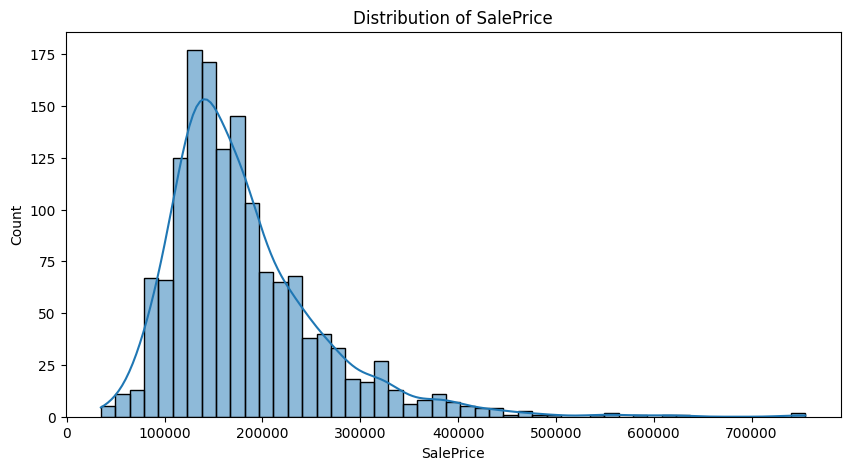

In [ ]:
# 1. 타겟 변수(SalePrice) 분포 확인
plt.figure(figsize=(10, 5))
sns.histplot(train_df['SalePrice'], kde=True)
plt.title('Distribution of SalePrice')
plt.show()

In [ ]:
# 2. 결측치 비율 확인 (비율이 높은 순으로 정렬)
missing_data = train_df.isnull().sum().sort_values(ascending=False)
missing_percentage = (train_df.isnull().sum() / len(train_df) * 100).sort_values(ascending=False)
missing_table = pd.concat([missing_data, missing_percentage], axis=1, keys=['Total', 'Percent'])

print("\n--- 결측치 상위 10개 컬럼 ---")
print(missing_table.head(10))


--- 결측치 상위 10개 컬럼 ---
              Total    Percent
PoolQC         1453  99.520548
MiscFeature    1406  96.301370
Alley          1369  93.767123
Fence          1179  80.753425
MasVnrType      872  59.726027
FireplaceQu     690  47.260274
LotFrontage     259  17.739726
GarageQual       81   5.547945
GarageFinish     81   5.547945
GarageType       81   5.547945


- 데이터가 너무 없는 컬럼 (PoolQC, MiscFeature, Alley, Fence 등):

이 컬럼들은 데이터의 80~90% 이상이 비어있습니다. 이 경우 해당 컬럼 자체를 삭제하는 것이 모델 학습에 더 도움이 될 수 있음

- 데이터가 조금 있는 컬럼 (GarageQual, BsmtQual 등):

카테고리형 데이터라면 "None"이라는 새로운 카테고리를 만들어 결측치를 채우고, 수치형 데이터라면 중앙값(Median)이나 최빈값으로 채우는(Imputation) 전략을 활용

In [ ]:
# 결측치 비율 계산
missing_count = train_df.isnull().sum()
missing_percent = (train_df.isnull().sum() / len(train_df)) * 100

# 결측치가 있는 컬럼만 필터링하여 확인
missing_df = pd.DataFrame({'Total': missing_count, 'Percent': missing_percent})
missing_df = missing_df[missing_df['Total'] > 0].sort_values(ascending=False, by='Total')

print(missing_df.head(15))

              Total    Percent
PoolQC         1453  99.520548
MiscFeature    1406  96.301370
Alley          1369  93.767123
Fence          1179  80.753425
MasVnrType      872  59.726027
FireplaceQu     690  47.260274
LotFrontage     259  17.739726
GarageType       81   5.547945
GarageYrBlt      81   5.547945
GarageFinish     81   5.547945
GarageQual       81   5.547945
GarageCond       81   5.547945
BsmtExposure     38   2.602740
BsmtFinType2     38   2.602740
BsmtQual         37   2.534247


In [ ]:
# 삭제할 컬럼 리스트 (결측치 80%이상 기준으로 판단)
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']

# 컬럼 삭제
train_df = train_df.drop(columns=cols_to_drop)

print(f"삭제 후 컬럼 수: {train_df.shape[1]}")

삭제 후 컬럼 수: 77


In [ ]:
# 1. 범주형 결측치를 'None'으로 채우기
cat_cols = ['MasVnrType', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
            'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1']
for col in cat_cols:
    train_df[col] = train_df[col].fillna('None')

# 2. 수치형 결측치를 중앙값으로 채우기
# LotFrontage는 도로 폭이므로 중앙값, GarageYrBlt는 차고 연도이므로 0으로 채우는 예시
train_df['LotFrontage'] = train_df['LotFrontage'].fillna(train_df['LotFrontage'].median())
train_df['GarageYrBlt'] = train_df['GarageYrBlt'].fillna(0)
train_df['MasVnrArea'] = train_df['MasVnrArea'].fillna(0)

# 3. 나머지는 최빈값으로 (Electrical 등 1개씩 비어있는 경우)
train_df = train_df.fillna(train_df.mode().iloc[0])

# 확인
print("남은 결측치 개수:", train_df.isnull().sum().sum())

남은 결측치 개수: 0


# 범주형 변수 수치화 (Label Encoding)
- 컴퓨터는 문자를 직접 이해하지 못하기 때문에, 범주형 데이터를 숫자로 바꿔줘야 함.
- 가장 간단하고 효과적인 Label Encoding을 적용해봄

## 1. 코드의 역할
범주형(Category) 데이터를 모델이 이해할 수 있도록 고유한 정수(0, 1, 2...)로 변환하는 과정임.

---

## 2. 주요 기능 및 사용 이유

### 💡 astype(str)을 쓰는 이유
* **데이터 타입의 일관성 유지**: 범주형 컬럼에는 문자열뿐만 아니라 결측치 처리 과정에서 남은 `None` 객체나 `float`형 데이터가 섞여 있을 수 있음.
* **인코딩 오류 방지**: `LabelEncoder`는 입력값이 일관된 타입(문자열)일 때 가장 안정적으로 작동하므로, 모든 데이터를 강제로 문자열로 통일하는 안전장치 역할을 함.

### ⚙️ le.fit_transform()의 역할
* **`fit`**: 데이터의 모든 고유 항목을 찾아 순서를 매김 (예: 'A', 'B', 'C' ➡️ 'A':0, 'B':1, 'C':2).
* **`transform`**: 실제 데이터를 정해진 규칙에 따라 정수로 변환함.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 범주형(object) 타입인 컬럼들만 찾아서 변환
cat_cols = train_df.select_dtypes(include=['object']).columns

for col in cat_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))

print("범주형 데이터 변환 완료!")
print(train_df.info())

범주형 데이터 변환 완료!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 77 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   int64  
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   int64  
 6   LotShape       1460 non-null   int64  
 7   LandContour    1460 non-null   int64  
 8   Utilities      1460 non-null   int64  
 9   LotConfig      1460 non-null   int64  
 10  LandSlope      1460 non-null   int64  
 11  Neighborhood   1460 non-null   int64  
 12  Condition1     1460 non-null   int64  
 13  Condition2     1460 non-null   int64  
 14  BldgType       1460 non-null   int64  
 15  HouseStyle     1460 non-null   int64  
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64 

# 상관관계 분석 (상위 10개 변수 추출)
- 이제 어떤 변수가 SalePrice와 가장 관련이 깊은지 확인
- 이 과정을 통해 중요하지 않은 변수를 걸러내거나, 어떤 특성을 가진 집이 비싼지 알 수 있음

--- SalePrice와 상관관계 높은 상위 10개 변수 ---
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


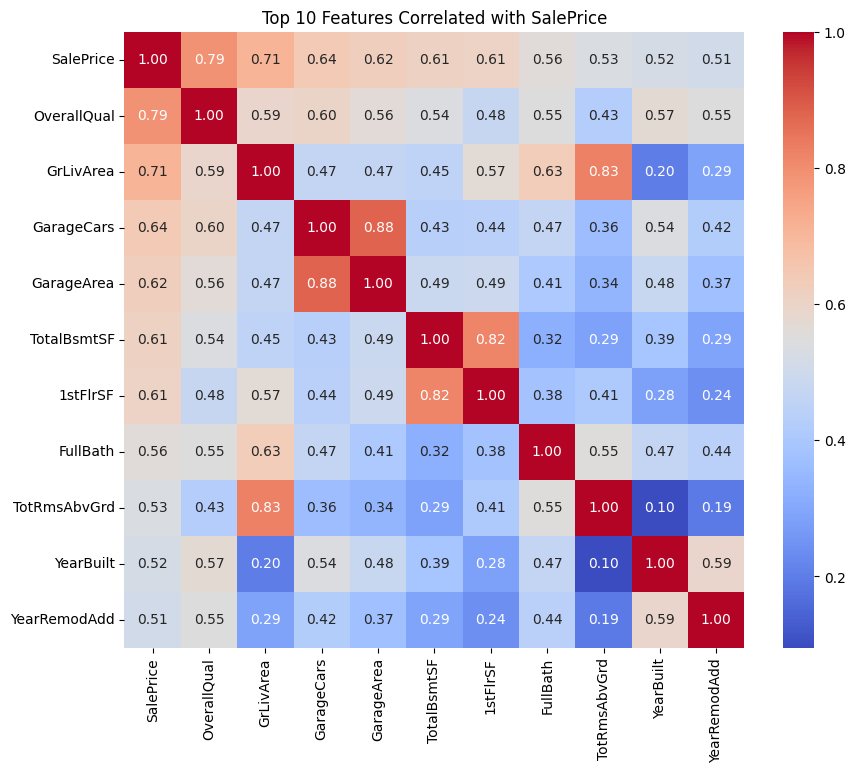

In [ ]:
# 상관관계 행렬 계산
corr_matrix = train_df.corr()

# SalePrice와 상관관계가 높은 상위 10개 변수 추출
top_10_corr = corr_matrix['SalePrice'].sort_values(ascending=False).head(11)
print("--- SalePrice와 상관관계 높은 상위 10개 변수 ---")
print(top_10_corr)

# 상관관계 시각화 (heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(train_df[top_10_corr.index].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 10 Features Correlated with SalePrice')
plt.show()

# 머신러닝 모델 학습 (RandomForest 예시)
회귀 문제에 자주 쓰이는 Random Forest Regressor 모델을 사용해 간단하게 가격을 예측

In [ ]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor

# 1. 데이터 로드
train_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/AI실무기본_2주차/02_머신러닝프로젝트진행과정/Kaggle_house_price/dataset/train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/AI실무기본_2주차/02_머신러닝프로젝트진행과정/Kaggle_house_price/dataset/test.csv')

# 2. train_df 전처리 (삭제 및 결측치 처리 - 앞서 했던 방식 그대로)
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
train_df = train_df.drop(columns=cols_to_drop)
# test_df도 똑같이 삭제 (중요!)
test_df = test_df.drop(columns=cols_to_drop)

# 3. 파이프라인 재구축
# 수치형과 범주형 컬럼을 'Id'와 'SalePrice'를 제외하고 명확히 분리
target = 'SalePrice'
numeric_features = train_df.select_dtypes(include=['int64', 'float64']).columns.drop(target)
categorical_features = train_df.select_dtypes(include=['object']).columns

# 파이프라인 정의
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')) # 중요: 없는 카테고리는 무시
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 모델 학습
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# 학습 실행
X = train_df.drop(target, axis=1)
y = train_df[target]
model_pipeline.fit(X, y)

# 4. 예측 수행
predictions = model_pipeline.predict(test_df)

# 5. 제출 파일 생성
submission = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/AI실무기본_2주차/02_머신러닝프로젝트진행과정/Kaggle_house_price/dataset/sample_submission.csv')
submission['SalePrice'] = predictions
submission.to_csv('my_submission.csv', index=False)

print("성공! my_submission.csv 파일이 생성되었습니다.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/AI실무기본_2주차/02_머신러닝프로젝트진행과정/Kaggle_house_price/dataset/sample_submission2.csv'